In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Dataset directories

DATA_PATH = "/content/drive/MyDrive/kitti/training"

VELODYNE_DIR = DATA_PATH + "/velodyne"
LABEL_DIR = DATA_PATH + "/label_2"

## Generate Predictions for Entire Dataset




In [ ]:
import numpy as np

# Attempt to load GPU DBSCAN, fallback to CPU if not installed
try:
    from cuml.cluster import DBSCAN
    print("GPU DBSCAN (cuml) imported successfully!")
except ImportError:
    from sklearn.cluster import DBSCAN
    print("Falling back to CPU DBSCAN (sklearn).")

def process_point_cloud_with_dbscan(raw_points):
    """
    Processes raw LiDAR points using DBSCAN to identify clusters and compute
    filtered 2D bounding boxes.
    """
    # Extract coordinates
    x = raw_points[:, 0]
    y = raw_points[:, 1]
    z = raw_points[:, 2]

    # Region filtering
    mask = (
        (x > 0) & (x < 70) &
        (y > -40) & (y < 40) &
        (z > -3) & (z < 1)
    )
    filtered_points = raw_points[mask]

    # Remove ground points
    ground_threshold = -1.5
    non_ground_points = filtered_points[filtered_points[:, 2] > ground_threshold]

    if non_ground_points.shape[0] == 0:
        return []

    # Normalize coordinates
    coords = non_ground_points[:, :3]
    std_dev = coords.std(axis=0)
    std_dev[std_dev == 0] = 1.0 # Avoid division by zero
    coords = (coords - coords.mean(axis=0)) / std_dev

    # Apply DBSCAN
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    cluster_labels = dbscan.fit_predict(coords)

    # Convert GPU output back to standard numpy array if needed
    if hasattr(cluster_labels, 'to_numpy'):
        cluster_labels = cluster_labels.to_numpy()
    elif hasattr(cluster_labels, 'get'):
        cluster_labels = cluster_labels.get()

    # Attach cluster IDs
    clustered_points = np.hstack((non_ground_points, cluster_labels.reshape(-1, 1)))

    # Compute cluster bounding boxes
    clusters = {}
    for point in clustered_points:
        cluster_id = int(point[4])
        if cluster_id == -1:  # Exclude noise points
            continue
        clusters.setdefault(cluster_id, []).append(point[:3])

    bboxes = []
    for cid, pts in clusters.items():
        pts = np.array(pts)
        if pts.shape[0] > 0:
            x_min, y_min, z_min = pts.min(axis=0)
            x_max, y_max, z_max = pts.max(axis=0)
            bboxes.append([x_min, y_min, x_max, y_max])

    # Cluster filtering
    filtered_boxes = []
    for box in bboxes:
        width = box[2] - box[0]
        length = box[3] - box[1]
        if width > 0.5 and length > 0.5:
            filtered_boxes.append(box)

    return filtered_boxes

print("Updated `process_point_cloud_with_dbscan` function with GPU support.")

GPU DBSCAN (cuml) imported successfully!
Updated `process_point_cloud_with_dbscan` function with GPU support.


In [ ]:
import os
import numpy as np
from tqdm import tqdm

# Re-define DATA_PATH and VELODYNE_DIR to ensure they are in scope
DATA_PATH = "/content/drive/MyDrive/kitti/training"
VELODYNE_DIR = DATA_PATH + "/velodyne"

# 1. Initialize an empty list called pred_infos
pred_infos = []

# Check if VELODYNE_DIR exists
if not os.path.exists(VELODYNE_DIR):
    print(f"Error: The directory {VELODYNE_DIR} does not exist. Please ensure the 'kitti/training/velodyne' folder is correctly placed in your Google Drive.")
    bin_file_paths = []
else:
    # 2. Get the list of validation .bin files from gt_infos
    if 'gt_infos' in globals() and len(gt_infos) > 0:
        print(f"Extracting validation frames from gt_infos (Total: {len(gt_infos)} frames)")
        bin_file_paths = []
        for info in gt_infos:
            frame_idx = None
            # Typically KITTI info dicts store the frame index here
            if 'point_cloud' in info and 'lidar_idx' in info['point_cloud']:
                frame_idx = info['point_cloud']['lidar_idx']
            elif 'image' in info and 'image_idx' in info['image']:
                frame_idx = info['image']['image_idx']

            if frame_idx is not None:
                bin_filename = f"{int(frame_idx):06d}.bin"
                bin_file_paths.append(os.path.join(VELODYNE_DIR, bin_filename))
            else:
                print("Warning: Could not find frame index in a gt_infos item.")
    else:
        print("Warning: gt_infos not found or empty. Defaulting to all .bin files.")
        velodyne_files = sorted(os.listdir(VELODYNE_DIR))
        bin_file_paths = [os.path.join(VELODYNE_DIR, f) for f in velodyne_files if f.endswith('.bin')]

print(f"Found {len(bin_file_paths)} .bin files to process.")

# 3. Loop through each .bin file path with a progress bar:
for i, bin_path in enumerate(tqdm(bin_file_paths, desc="Processing LiDAR frames")):
    if not os.path.exists(bin_path):
        # Append empty prediction if file is missing to keep alignment with gt_infos
        pred_infos.append({
            'name': np.array([], dtype=str),
            'bbox': np.array([], dtype=np.float32).reshape(0,4),
            'score': np.array([], dtype=np.float32)
        })
        continue

    # a. Load the raw LiDAR points
    raw_points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)

    # b. Call the process_point_cloud_with_dbscan function
    detected_bboxes = process_point_cloud_with_dbscan(raw_points)

    # Initialize lists to store prediction details for the current frame
    current_frame_names = []
    current_frame_bboxes = []
    current_frame_scores = []

    # c. For each detected bounding box, create a dictionary
    for bbox in detected_bboxes:
        current_frame_names.append('Car') # Assign 'Car' as class name
        current_frame_bboxes.append(bbox) # The 2D bounding box [x_min, y_min, x_max, y_max]
        current_frame_scores.append(1.0) # Dummy score of 1.0

    # If no boxes are detected, ensure arrays are empty but have correct dimensions if accessed later
    if not current_frame_names:
        current_frame_names = np.array([], dtype=str)
        current_frame_bboxes = np.array([], dtype=np.float32).reshape(0,4)
        current_frame_scores = np.array([], dtype=np.float32)
    else:
        current_frame_names = np.array(current_frame_names)
        current_frame_bboxes = np.array(current_frame_bboxes)
        current_frame_scores = np.array(current_frame_scores)

    # d. Append these to the pred_infos structure for the current frame
    frame_pred_info = {
        'name': current_frame_names,
        'bbox': current_frame_bboxes,
        'score': current_frame_scores
    }
    pred_infos.append(frame_pred_info)

# 4. Print the total number of frames and a sample of pred_infos
print(f"\nGenerated predictions for {len(pred_infos)} frames.")
if len(pred_infos) > 0:
    print("\nSample pred_infos for the first frame:")
    # Limit output for readability
    sample_info = pred_infos[0]
    print(f"  Number of detected objects: {len(sample_info['name'])}")
    if len(sample_info['name']) > 0:
        print(f"  First object name: {sample_info['name'][0]}")
        print(f"  First object bbox: {sample_info['bbox'][0]}")
        print(f"  First object score: {sample_info['score'][0]}")
    else:
        print("  No objects detected in the first frame.")
else:
    print("No predictions were generated.")

Extracting validation frames from gt_infos (Total: 3769 frames)
Found 3769 .bin files to process.


Processing LiDAR frames:   4%|▎         | 138/3769 [04:24<1:44:51,  1.73s/it]

[2026-03-21 14:42:18.633] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 48775 -> 44028. Using the larger integer type might result in better performance


Processing LiDAR frames:   9%|▉         | 354/3769 [10:14<1:30:32,  1.59s/it]

[2026-03-21 14:48:09.010] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 47877 -> 44854. Using the larger integer type might result in better performance


...

[2026-03-21 16:15:43.746] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 46986 -> 45704. Using the larger integer type might result in better performance


Processing LiDAR frames:  95%|█████████▌| 3584/3769 [1:38:17<05:03,  1.64s/it]

[2026-03-21 16:16:11.905] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 47649 -> 45068. Using the larger integer type might result in better performance


Processing LiDAR frames: 100%|██████████| 3769/3769 [1:43:29<00:00,  1.65s/it]


Generated predictions for 3769 frames.

Sample pred_infos for the first frame:
  Number of detected objects: 1
  First object name: Car
  First object bbox: [ 2.00000009e-03 -2.07010002e+01  6.38680000e+01  3.78320007e+01]
  First object score: 1.0


In [ ]:
# Install NVIDIA RAPIDS cuML for GPU-accelerated clustering
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 200.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82



**Evaluation**



In [ ]:
import pickle
import os

# Define the path to save the predictions
save_path = '/content/drive/MyDrive/kitti/dbscan_val_predictions.pkl'

# Check if pred_infos exists and save it
if 'pred_infos' in globals() and len(pred_infos) > 0:
    try:
        with open(save_path, 'wb') as f:
            pickle.dump(pred_infos, f)
        print(f"Successfully saved {len(pred_infos)} frames of predictions to:\n{save_path}")
    except Exception as e:
        print(f"An error occurred while saving: {e}")
else:
    print("Error: 'pred_infos' variable is empty or not found. Please ensure the DBSCAN prediction cell has finished running.")

Successfully saved 3769 frames of predictions to:
/content/drive/MyDrive/kitti/dbscan_val_predictions.pkl


In [ ]:
import pickle
import os
import numpy as np
import copy

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'numpy.core.multiarray':
            module = 'numpy._core.multiarray'
        return super().find_class(module, name)

# Load ground truth
gt_path = '/content/drive/MyDrive/kitti/kitti_infos_val.pkl'
gt_infos = []  # Initialize to avoid NameError if file is not found
try:
    with open(gt_path, 'rb') as f:
        gt_infos = CustomUnpickler(f).load()
    print(f"Successfully loaded ground truth from {gt_path}")
except FileNotFoundError:
    print(f"Ground truth file {gt_path} not found.")
except Exception as e:
    print(f"Failed to load {gt_path}: {e}")

# Load the saved 2D DBSCAN predictions
pred_path = '/content/drive/MyDrive/kitti/dbscan_val_predictions_2d.pkl'

if os.path.exists(pred_path):
    try:
        with open(pred_path, 'rb') as f:
            pred_infos = CustomUnpickler(f).load()
        print(f"Successfully loaded 2D DBSCAN predictions from {pred_path}")
    except Exception as e:
        print(f"Failed to load predictions: {e}")
        pred_infos = []
else:
    print(f"Prediction file {pred_path} not found. Please ensure the DBSCAN prediction and saving cells have finished running.")
    pred_infos = []

Successfully loaded ground truth from /content/drive/MyDrive/kitti/kitti_infos_val.pkl
Successfully loaded 2D DBSCAN predictions from /content/drive/MyDrive/kitti/dbscan_val_predictions_2d.pkl


In [ ]:
def calculate_iou_2d(box1, box2):
    """
    Calculate the 2D Intersection over Union (IoU) of two bounding boxes.

    Parameters:
    box1 (list or tuple): [x_min, y_min, x_max, y_max]
    box2 (list or tuple): [x_min, y_min, x_max, y_max]

    Returns:
    float: IoU value
    """
    # Determine the coordinates of the intersection rectangle
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    # Calculate the area of intersection rectangle
    intersection_area = max(0, x_right - x_left) * max(0, y_bottom - y_top)

    # Calculate the area of both bounding boxes
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Calculate the union area
    union_area = box1_area + box2_area - intersection_area

    # Compute the Intersection over Union
    if union_area == 0:
        return 0.0

    iou = intersection_area / union_area
    return iou

print("Defined calculate_iou_2d function.")


Defined calculate_iou_2d function.


In [ ]:
def extract_prediction_matches(pred_infos, gt_infos, target_class='Car', iou_threshold=0.5):
    results = []
    num_frames = min(len(pred_infos), len(gt_infos))

    for i in range(num_frames):
        pred = pred_infos[i]
        gt = gt_infos[i]

        if 'name' in pred and 'bbox' in pred and 'score' in pred:
            pred_names = pred['name']
            pred_bboxes = pred['bbox']
            pred_scores = pred['score']
        else:
            continue

        class_mask = pred_names == target_class
        pred_bboxes_cls = pred_bboxes[class_mask]
        pred_scores_cls = pred_scores[class_mask]

        if 'annos' in gt and 'name' in gt['annos'] and 'bbox' in gt['annos']:
            gt_names = gt['annos']['name']
            gt_bboxes = gt['annos']['bbox']
        else:
            gt_names = np.array([])
            gt_bboxes = np.array([])

        gt_class_mask = gt_names == target_class
        gt_bboxes_cls = gt_bboxes[gt_class_mask]

        matched_gt = np.zeros(len(gt_bboxes_cls), dtype=bool)

        for pred_box, score in zip(pred_bboxes_cls, pred_scores_cls):
            best_iou = 0.0
            best_gt_idx = -1

            for j, gt_box in enumerate(gt_bboxes_cls):
                if matched_gt[j]:
                    continue
                iou = calculate_iou_2d(pred_box, gt_box)
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = j

            if best_iou >= iou_threshold and best_gt_idx != -1:
                matched_gt[best_gt_idx] = True
                results.append({'score': score, 'tp': 1, 'fp': 0, 'iou': best_iou})
            else:
                results.append({'score': score, 'tp': 0, 'fp': 1, 'iou': best_iou})

    return results

prediction_matches = extract_prediction_matches(pred_infos, gt_infos, target_class='Car', iou_threshold=0.5)
print(f"Extracted {len(prediction_matches)} prediction matches.")
if len(prediction_matches) > 0:
    print(f"Sample match: {prediction_matches[0]}")

Extracted 7719 prediction matches.
Sample match: {'score': np.float32(1.0), 'tp': 0, 'fp': 1, 'iou': np.float32(0.0016821958)}


In [ ]:
import numpy as np

def evaluate_class_2d(target_class, prediction_matches, gt_infos):
    # 1. Calculate total ground truth boxes for the target class
    total_gt = 0
    for gt in gt_infos:
        if 'annos' in gt and 'name' in gt['annos']:
            gt_names = gt['annos']['name']
            total_gt += np.sum(gt_names == target_class)

    # Handle edge case: no ground truth or predictions
    if total_gt == 0 or len(prediction_matches) == 0:
        return {
            'AP': 0.0,
            'optimal_threshold': 0.0,
            'optimal_precision': 0.0,
            'optimal_recall': 0.0,
            'optimal_f1': 0.0,
            'optimal_avg_iou': 0.0,
            'recall_array': np.array([]),
            'precision_array': np.array([])
        }

    # 2. Sort prediction matches by score descending
    sorted_matches = sorted(prediction_matches, key=lambda x: x['score'], reverse=True)

    # 3. Extract tp, fp, scores, and ious
    tp_array = np.array([m['tp'] for m in sorted_matches])
    fp_array = np.array([m['fp'] for m in sorted_matches])
    scores_array = np.array([m['score'] for m in sorted_matches])

    # 4. Compute cumulative tp and fp
    cum_tp = np.cumsum(tp_array)
    cum_fp = np.cumsum(fp_array)

    # 5. Calculate precision and recall
    precision = cum_tp / (cum_tp + cum_fp)
    precision[np.isnan(precision)] = 0
    recall = cum_tp / total_gt

    # Make precision monotonically decreasing for AP calculation
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))
    for i in range(mpre.size - 1, 0, -1):
        mpre[i - 1] = np.maximum(mpre[i - 1], mpre[i])

    # Calculate AP
    i = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[i + 1] - mrec[i]) * mpre[i + 1])

    # 6. Compute F1-scores and find optimal threshold
    f1_scores = 2 * (precision * recall) / (precision + recall)
    f1_scores = np.nan_to_num(f1_scores, nan=0.0)
    optimal_idx = np.argmax(f1_scores)

    optimal_threshold = scores_array[optimal_idx]
    optimal_precision = precision[optimal_idx]
    optimal_recall = recall[optimal_idx]
    optimal_f1 = f1_scores[optimal_idx]

    # 7. Calculate average IoU for true positives >= optimal threshold
    filtered_matches = [m for m in sorted_matches if m['score'] >= optimal_threshold and m['tp'] == 1]
    tp_ious = [m['iou'] for m in filtered_matches]
    optimal_avg_iou = np.mean(tp_ious) if tp_ious else 0.0

    # 8. Return metrics dictionary
    return {
        'AP': ap,
        'optimal_threshold': optimal_threshold,
        'optimal_precision': optimal_precision,
        'optimal_recall': optimal_recall,
        'optimal_f1': optimal_f1,
        'optimal_avg_iou': optimal_avg_iou,
        'recall_array': recall,
        'precision_array': precision
    }

print("Defined evaluate_class_2d function.")


Defined evaluate_class_2d function.


Evaluating class: Car...


/tmp/ipykernel_6476/373952992.py:52: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


Evaluating class: Cyclist...
No valid data to plot for Cyclist.
Evaluating class: Pedestrian...
No valid data to plot for Pedestrian.


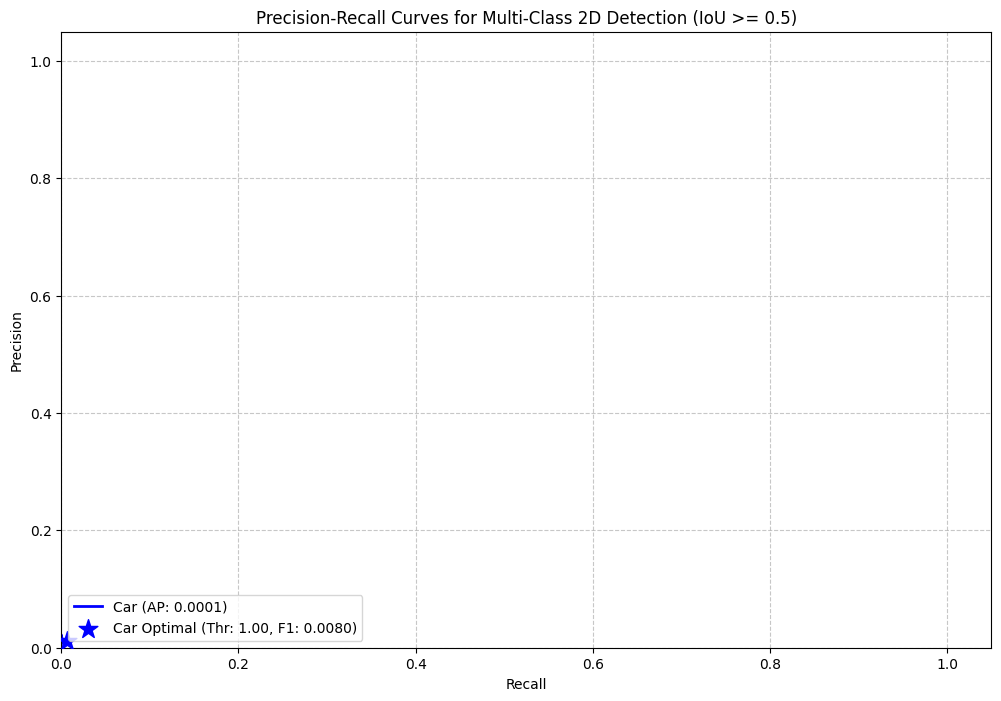


--- Multi-Class 2D Detection Summary (IoU >= 0.5) ---

Class: Car
  Average Precision (AP): 0.0001
  Optimal Confidence Threshold: 1.0000
  Precision at Optimal: 0.0114
  Recall at Optimal: 0.0061
  Max F1-score: 0.0080
  Average IoU at Optimal: 0.6207

Class: Cyclist
  Average Precision (AP): 0.0000
  Optimal Confidence Threshold: 0.0000
  Precision at Optimal: 0.0000
  Recall at Optimal: 0.0000
  Max F1-score: 0.0000
  Average IoU at Optimal: 0.0000

Class: Pedestrian
  Average Precision (AP): 0.0000
  Optimal Confidence Threshold: 0.0000
  Precision at Optimal: 0.0000
  Recall at Optimal: 0.0000
  Max F1-score: 0.0000
  Average IoU at Optimal: 0.0000


In [ ]:
import matplotlib.pyplot as plt

classes_to_evaluate = ['Car', 'Cyclist', 'Pedestrian']
all_class_metrics = {}

plt.figure(figsize=(12, 8))
colors = ['blue', 'green', 'orange']

for idx, cls in enumerate(classes_to_evaluate):
    print(f"Evaluating class: {cls}...")
    # Extract matches for the specific class
    matches = extract_prediction_matches(pred_infos, gt_infos, target_class=cls, iou_threshold=0.5)

    # Evaluate metrics
    metrics = evaluate_class_2d(cls, matches, gt_infos)
    all_class_metrics[cls] = metrics

    if metrics['recall_array'].size > 0 and metrics['precision_array'].size > 0:
        # Plot PR curve
        plt.plot(metrics['recall_array'], metrics['precision_array'], color=colors[idx],
                 label=f"{cls} (AP: {metrics['AP']:.4f})", linewidth=2)

        # Highlight optimal threshold
        plt.scatter(metrics['optimal_recall'], metrics['optimal_precision'], marker='*', s=200, color=colors[idx], zorder=5,
                    label=f"{cls} Optimal (Thr: {metrics['optimal_threshold']:.2f}, F1: {metrics['optimal_f1']:.4f})")
    else:
        print(f"No valid data to plot for {cls}.")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves for Multi-Class 2D Detection (IoU >= 0.5)')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.show()

# Print summary
print("\n--- Multi-Class 2D Detection Summary (IoU >= 0.5) ---")
for cls, m in all_class_metrics.items():
    print(f"\nClass: {cls}")
    print(f"  Average Precision (AP): {m['AP']:.4f}")
    print(f"  Optimal Confidence Threshold: {m['optimal_threshold']:.4f}")
    print(f"  Precision at Optimal: {m['optimal_precision']:.4f}")
    print(f"  Recall at Optimal: {m['optimal_recall']:.4f}")
    print(f"  Max F1-score: {m['optimal_f1']:.4f}")
    print(f"  Average IoU at Optimal: {m['optimal_avg_iou']:.4f}")

In [ ]:
import os
import numpy as np
from tqdm import tqdm
import pickle

# Ensure GPU cuML is used
try:
    from cuml.cluster import DBSCAN
except ImportError:
    from sklearn.cluster import DBSCAN
    print("Warning: cuML not found, using CPU DBSCAN.")

def process_and_project_dbscan(raw_points, calib, image_shape):
    # 1. Basic LiDAR processing
    x, y, z = raw_points[:, 0], raw_points[:, 1], raw_points[:, 2]
    mask = (x > 0) & (x < 70) & (y > -40) & (y < 40) & (z > -3) & (z < 1)
    filtered_points = raw_points[mask]

    ground_threshold = -1.5
    non_ground_points = filtered_points[filtered_points[:, 2] > ground_threshold]

    if non_ground_points.shape[0] == 0:
        return []

    # 2. DBSCAN Clustering
    coords = non_ground_points[:, :3]
    std_dev = coords.std(axis=0)
    std_dev[std_dev == 0] = 1.0
    coords = (coords - coords.mean(axis=0)) / std_dev

    dbscan = DBSCAN(eps=0.5, min_samples=10)
    cluster_labels = dbscan.fit_predict(coords)

    if hasattr(cluster_labels, 'to_numpy'):
        cluster_labels = cluster_labels.to_numpy()
    elif hasattr(cluster_labels, 'get'):
        cluster_labels = cluster_labels.get()

    clustered_points = np.hstack((non_ground_points, cluster_labels.reshape(-1, 1)))

    clusters = {}
    for point in clustered_points:
        cluster_id = int(point[4])
        if cluster_id == -1:
            continue
        clusters.setdefault(cluster_id, []).append(point[:3])

    # 3. Project Clusters to 2D Image Space
    bboxes = []
    for cid, pts in clusters.items():
        pts = np.array(pts)
        pts_hom = np.hstack((pts, np.ones((pts.shape[0], 1)))) # Make homogeneous

        # Prepare matrices safely handling 3x3, 3x4, or 4x4 shapes
        Tr = np.eye(4)
        Tr[:calib['Tr_velo_to_cam'].shape[0], :calib['Tr_velo_to_cam'].shape[1]] = calib['Tr_velo_to_cam']

        R0 = np.eye(4)
        R0[:calib['R0_rect'].shape[0], :calib['R0_rect'].shape[1]] = calib['R0_rect']

        P2 = np.eye(4)
        P2[:calib['P2'].shape[0], :calib['P2'].shape[1]] = calib['P2']

        # Matrix multiplication: Point -> Cam -> Rectified -> Image
        pts_cam = (Tr @ pts_hom.T).T
        pts_rect = (R0 @ pts_cam.T).T
        pts_img = (P2 @ pts_rect.T).T

        # Filter points that are behind the camera (depth Z <= 0.1)
        depth = pts_img[:, 2]
        valid_mask = depth > 0.1
        if not np.any(valid_mask):
            continue

        pts_img = pts_img[valid_mask]

        # Convert to pixel coordinates
        u = pts_img[:, 0] / pts_img[:, 2]
        v = pts_img[:, 1] / pts_img[:, 2]

        u_min, u_max = u.min(), u.max()
        v_min, v_max = v.min(), v.max()

        # Clip to image dimensions
        img_h, img_w = image_shape
        u_min = max(0, u_min)
        v_min = max(0, v_min)
        u_max = min(img_w - 1, u_max)
        v_max = min(img_h - 1, v_max)

        # Keep boxes that are reasonably sized in the image
        if u_max - u_min > 15 and v_max - v_min > 15:
            bboxes.append([u_min, v_min, u_max, v_max])

    return bboxes

# --- Execution Loop ---
VELODYNE_DIR = "/content/drive/MyDrive/kitti/training/velodyne"
pred_infos = []

print(f"Projecting 3D clusters to 2D image space for {len(gt_infos)} validation frames...")
for info in tqdm(gt_infos, desc="Processing & Projecting"):
    frame_idx = info['point_cloud']['lidar_idx'] if 'point_cloud' in info else info['image']['image_idx']
    bin_path = os.path.join(VELODYNE_DIR, f"{int(frame_idx):06d}.bin")

    if not os.path.exists(bin_path):
        pred_infos.append({'name': np.array([], dtype=str), 'bbox': np.array([], dtype=np.float32).reshape(0,4), 'score': np.array([], dtype=np.float32)})
        continue

    raw_points = np.fromfile(bin_path, dtype=np.float32).reshape(-1, 4)

    # Get calibration and image shapes from ground truth info
    calib = info['calib']
    image_shape = info['image']['image_shape']

    # Get projected 2D boxes
    detected_2d_bboxes = process_and_project_dbscan(raw_points, calib, image_shape)

    if len(detected_2d_bboxes) == 0:
        pred_infos.append({'name': np.array([], dtype=str), 'bbox': np.array([], dtype=np.float32).reshape(0,4), 'score': np.array([], dtype=np.float32)})
    else:
        pred_infos.append({
            'name': np.array(['Car'] * len(detected_2d_bboxes)),
            'bbox': np.array(detected_2d_bboxes, dtype=np.float32),
            'score': np.ones(len(detected_2d_bboxes), dtype=np.float32)
        })

# Save the new correctly scaled predictions
save_path = '/content/drive/MyDrive/kitti/dbscan_val_predictions_2d.pkl'
try:
    with open(save_path, 'wb') as f:
        pickle.dump(pred_infos, f)
    print(f"\nSuccessfully saved 2D projected predictions to:\n{save_path}")
except Exception as e:
    print(f"Error saving: {e}")

Projecting 3D clusters to 2D image space for 3769 validation frames...


Processing & Projecting:   4%|▎         | 138/3769 [00:24<09:52,  6.13it/s]

[2026-03-21 16:30:56.001] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 48775 -> 44028. Using the larger integer type might result in better performance


Processing & Projecting:   9%|▉         | 354/3769 [00:57<09:45,  5.84it/s]

[2026-03-21 16:31:29.379] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 47877 -> 44854. Using the larger integer type might result in better performance


...

[2026-03-21 16:39:33.533] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 46986 -> 45704. Using the larger integer type might result in better performance


Processing & Projecting:  95%|█████████▌| 3583/3769 [09:04<00:34,  5.32it/s]

[2026-03-21 16:39:36.399] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 47649 -> 45068. Using the larger integer type might result in better performance


Processing & Projecting: 100%|██████████| 3769/3769 [09:34<00:00,  6.56it/s]


Successfully saved 2D projected predictions to:
/content/drive/MyDrive/kitti/dbscan_val_predictions_2d.pkl
